# Tomato Leaf Disease Detection - FIXED VERSION
### Custom CNN Model for 10 Disease Classes
**Fixes Applied:**
- ✅ Proper data augmentation pipeline
- ✅ Consistent normalization (0-1 scaling)
- ✅ Deeper CNN architecture with regularization
- ✅ Learning rate scheduling
- ✅ Class weight balancing
- ✅ Fixed prediction pipeline
- ✅ Comprehensive evaluation metrics

## 1. Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import os

print(f"TensorFlow Version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)


TensorFlow Version: 2.15.0
GPU Available: []


## 2. Configuration Parameters

In [2]:
# Hyperparameters
IMAGE_SIZE = 128
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50
LEARNING_RATE = 0.001

# Dataset path - CHANGE THIS TO YOUR PATH
DATASET_PATH = r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset"

# Model save path
MODEL_SAVE_PATH = "best_tomato_disease_model.keras"

## 3. Load and Explore Dataset

In [3]:
# Load dataset
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    DATASET_PATH,
    shuffle=True,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    seed=42
)

class_names = dataset.class_names
n_classes = len(class_names)

print(f"Number of classes: {n_classes}")
print(f"Class names: {class_names}")
print(f"Total batches: {len(dataset)}")

Found 18160 files belonging to 10 classes.
Number of classes: 10
Class names: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Tomato_mosaic_virus', 'Tomato___healthy']
Total batches: 568


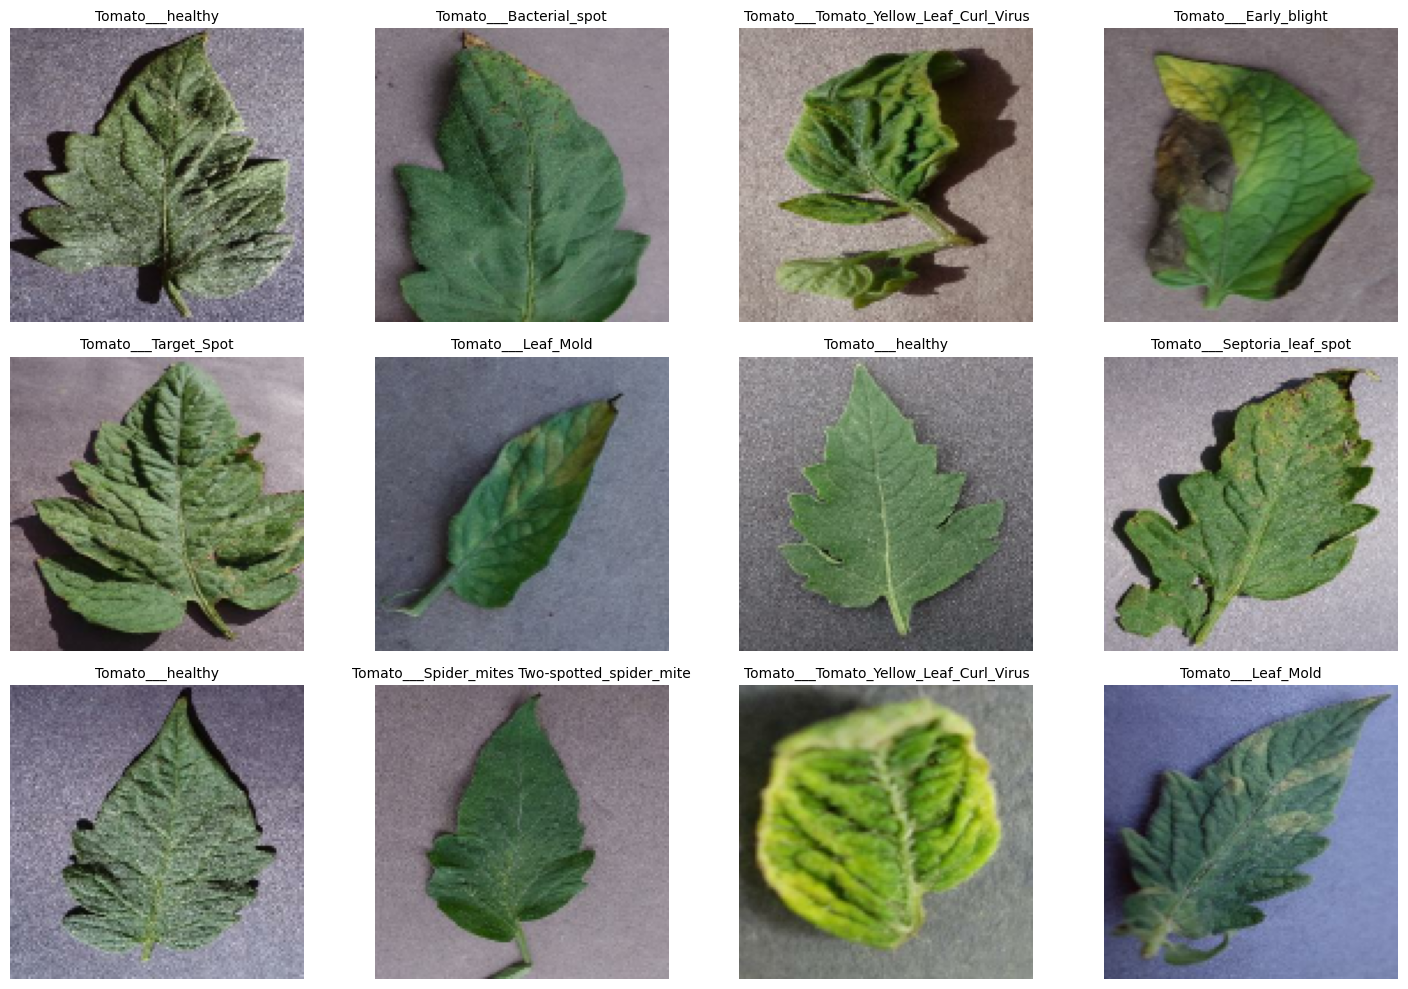

In [4]:
# Visualize sample images
plt.figure(figsize=(15, 10))
for image_batch, label_batch in dataset.take(1):
    for i in range(min(12, len(image_batch))):
        ax = plt.subplot(3, 4, i + 1)
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.title(class_names[label_batch[i]], fontsize=10)
        plt.axis("off")
plt.tight_layout()
plt.show()

## 4. Dataset Splitting and Preprocessing

In [5]:
def get_dataset_partitions(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    """
    Split dataset into train, validation, and test sets
    """
    assert (train_split + val_split + test_split) == 1.0, "Splits must sum to 1.0"
    
    ds_size = len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=42, reshuffle_each_iteration=False)
    
    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size + val_size)
    
    return train_ds, val_ds, test_ds

# Split dataset
train_ds, val_ds, test_ds = get_dataset_partitions(dataset)

print(f"Training batches: {len(train_ds)}")
print(f"Validation batches: {len(val_ds)}")
print(f"Test batches: {len(test_ds)}")

Training batches: 454
Validation batches: 56
Test batches: 58


## 5. Calculate Class Weights (Handle Imbalanced Data)

In [6]:
# Extract all labels from training dataset
train_labels = []
for _, labels in train_ds:
    train_labels.extend(labels.numpy())

train_labels = np.array(train_labels)

# Calculate class weights
class_weights_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights_values))

print("Class weights:")
for i, weight in class_weights.items():
    print(f"  {class_names[i]}: {weight:.3f}")

Class weights:
  Tomato___Bacterial_spot: 0.852
  Tomato___Early_blight: 1.887
  Tomato___Late_blight: 0.945
  Tomato___Leaf_Mold: 1.915
  Tomato___Septoria_leaf_spot: 1.036
  Tomato___Spider_mites Two-spotted_spider_mite: 1.085
  Tomato___Target_Spot: 1.281
  Tomato___Tomato_Yellow_Leaf_Curl_Virus: 0.339
  Tomato___Tomato_mosaic_virus: 4.742
  Tomato___healthy: 1.125


## 6. Data Augmentation Pipeline

In [7]:
# FIX: Create comprehensive data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.3),  # Increased rotation
    layers.RandomZoom(0.2),      # Added zoom
    layers.RandomContrast(0.2),  # Added contrast
    layers.RandomBrightness(0.2) # Added brightness
], name="data_augmentation")

# Normalization layer (0-1 scaling)
normalization = layers.Rescaling(1./255, name="normalization")

# FIX: Apply augmentation only to training data
def prepare_dataset(ds, augment=False, shuffle_buffer=1000):
    """
    Prepare dataset with proper augmentation and optimization
    """
    # Normalize all datasets
    ds = ds.map(lambda x, y: (normalization(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    
    # Apply augmentation only for training
    if augment:
        ds = ds.map(lambda x, y: (data_augmentation(x, training=True), y), 
                   num_parallel_calls=tf.data.AUTOTUNE)
    
    # Cache, shuffle, and prefetch
    ds = ds.cache()
    if augment:
        ds = ds.shuffle(shuffle_buffer)
    ds = ds.prefetch(buffer_size=tf.data.AUTOTUNE)
    
    return ds

# Prepare datasets
train_ds_prepared = prepare_dataset(train_ds, augment=True)
val_ds_prepared = prepare_dataset(val_ds, augment=False)
test_ds_prepared = prepare_dataset(test_ds, augment=False)

print("✅ Datasets prepared with augmentation applied to training only")


✅ Datasets prepared with augmentation applied to training only


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..132.74274].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [36.42194..215.57628].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [38.6167..233.46844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [28.141582..222.16444].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..168.61963].


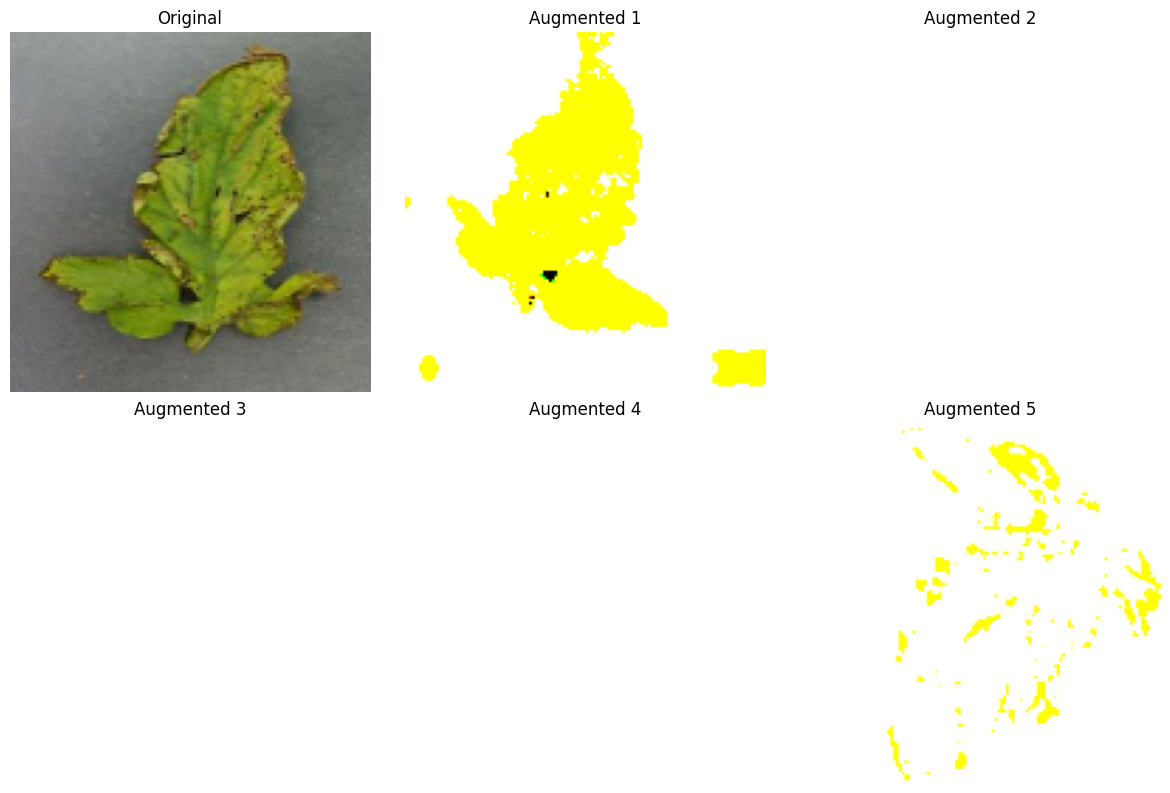

In [8]:
# Visualize augmentation effects
plt.figure(figsize=(12, 8))
for images, labels in train_ds.take(1):
    # Original
    plt.subplot(2, 3, 1)
    plt.imshow(images[0].numpy().astype("uint8"))
    plt.title("Original")
    plt.axis("off")
    
    # Augmented samples
    for i in range(5):
        augmented = data_augmentation(images[0:1], training=True)
        plt.subplot(2, 3, i + 2)
        plt.imshow(augmented[0].numpy())
        plt.title(f"Augmented {i+1}")
        plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Build Improved CNN Model

In [9]:
# FIX: Deeper architecture with proper regularization
def build_custom_cnn(input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), num_classes=n_classes):
    """
    Custom CNN architecture optimized for leaf disease detection
    
    Improvements:
    - Deeper architecture (5 conv blocks)
    - L2 regularization to prevent overfitting
    - Batch normalization for faster convergence
    - Global Average Pooling to reduce parameters
    - Dropout for regularization
    """
    
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.3),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        # Block 4
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(256, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.4),
        
        # Block 5
        layers.Conv2D(512, (3, 3), padding='same', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.GlobalAveragePooling2D(),
        
        # Dense layers
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        
        # Output layer
        layers.Dense(num_classes, activation='softmax')
    ], name="Custom_CNN_Tomato_Disease")
    
    return model

# Build model
model = build_custom_cnn()
model.summary()


Model: "Custom_CNN_Tomato_Disease"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 128, 128, 32)      128       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 128, 128, 32)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 batch_normalization_1 (Bat  (None, 128, 128, 32)      128       
 chNormalization)                                                
                                                                 
 activation_1 (Activation)   (None, 128,

## 8. Compile Model with Optimizations

In [10]:
# FIX: Better optimizer configuration
optimizer = tf.keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-07
)

model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top_3_accuracy')
    ]
)

print("✅ Model compiled successfully")

✅ Model compiled successfully


## 9. Setup Callbacks

In [11]:
# FIX: Comprehensive callbacks
callbacks = [
    # Save best model
    ModelCheckpoint(
        MODEL_SAVE_PATH,
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    ),
    
    # Early stopping
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Learning rate reduction
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
]

print("✅ Callbacks configured")

✅ Callbacks configured


## 10. Train Model

In [12]:
# Train the model
print("🚀 Starting training...\n")

history = model.fit(
    train_ds_prepared,
    validation_data=val_ds_prepared,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weights,  # FIX: Use class weights
    verbose=1
)

print("\n✅ Training completed!")

🚀 Starting training...

Epoch 1/50


454/454 [==============================] - ETA: 0s - loss: 4.3916 - accuracy: 0.0941 - top_3_accuracy: 0.3030
Epoch 1: val_accuracy improved from -inf to 0.09208, saving model to best_tomato_disease_model.keras
454/454 [==============================] - 585s 1s/step - loss: 4.3916 - accuracy: 0.0941 - top_3_accuracy: 0.3030 - val_loss: 3.5150 - val_accuracy: 0.0921 - val_top_3_accuracy: 1.0000 - lr: 0.0010
Epoch 2/50
454/454 [==============================] - ETA: 0s - loss: 3.5413 - accuracy: 0.0898 - top_3_accuracy: 0.2917
Epoch 2: val_accuracy did not improve from 0.09208
454/454 [==============================] - 922s 2s/step - loss: 3.5413 - accuracy: 0.0898 - top_3_accuracy: 0.2917 - val_loss: 3.0768 - val_accuracy: 0.0631 - val_top_3_accuracy: 1.0000 - lr: 0.0010
Epoch 3/50
454/454 [==============================] - ETA: 0s - loss: 3.0267 - accuracy: 0.0874 - top_3_accuracy: 0.3023
Epoch 3: val_accuracy improved from 0.09208 to 0.09654, savin

KeyboardInterrupt: 

## 11. Training Visualization

In [ ]:
# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Accuracy plot
    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
    axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Loss plot
    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
    axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Print final metrics
    print("\n📊 Final Training Metrics:")
    print(f"  Train Accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"  Val Accuracy: {history.history['val_accuracy'][-1]:.4f}")
    print(f"  Train Loss: {history.history['loss'][-1]:.4f}")
    print(f"  Val Loss: {history.history['val_loss'][-1]:.4f}")

plot_training_history(history)

## 12. Load Best Model and Evaluate

In [ ]:
# Load the best saved model
best_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f"✅ Loaded best model from {MODEL_SAVE_PATH}")

# Evaluate on test set
print("\n📊 Test Set Evaluation:")
test_loss, test_acc, test_top3 = best_model.evaluate(test_ds_prepared, verbose=1)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Top-3 Accuracy: {test_top3:.4f}")
print(f"Test Loss: {test_loss:.4f}")

## 13. Confusion Matrix and Classification Report

In [ ]:
# Generate predictions
print("Generating predictions...")
y_true = []
y_pred = []

for images, labels in test_ds_prepared:
    predictions = best_model.predict(images, verbose=0)
    predicted_labels = np.argmax(predictions, axis=1)
    
    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"Total test samples: {len(y_true)}")
print(f"Unique classes in predictions: {np.unique(y_pred)}")
print(f"Unique classes in ground truth: {np.unique(y_true)}")

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix - Tomato Disease Detection', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
# Classification Report
print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

## 14. Per-Class Accuracy Analysis

In [ ]:
# Calculate per-class accuracy
class_accuracy = []
for i in range(n_classes):
    class_mask = (y_true == i)
    if class_mask.sum() > 0:
        acc = (y_pred[class_mask] == i).sum() / class_mask.sum()
        class_accuracy.append((class_names[i], acc, class_mask.sum()))

# Sort by accuracy
class_accuracy.sort(key=lambda x: x[1], reverse=True)

print("\n📊 Per-Class Accuracy:\n")
print(f"{'Class':<40} {'Accuracy':<12} {'Samples'}")
print("-" * 65)
for name, acc, count in class_accuracy:
    print(f"{name:<40} {acc:>7.2%}      {count:>5}")

# Visualization
plt.figure(figsize=(12, 6))
names, accs, counts = zip(*class_accuracy)
colors = plt.cm.RdYlGn(np.array(accs))
bars = plt.barh(names, accs, color=colors)
plt.xlabel('Accuracy', fontsize=12)
plt.title('Per-Class Accuracy', fontsize=14, fontweight='bold')
plt.xlim(0, 1)
plt.axvline(x=np.mean(accs), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(accs):.2%}')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 15. Prediction Function for New Images

In [ ]:
# FIX: Correct prediction function with proper normalization
def predict_disease(img_path, model, class_names, top_k=3):
    """
    Predict disease from an image file
    
    Args:
        img_path: Path to image file
        model: Trained model
        class_names: List of class names
        top_k: Number of top predictions to show
    """
    from tensorflow.keras.preprocessing import image
    
    # Load and preprocess image
    img = image.load_img(img_path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
    img_array = image.img_to_array(img)
    
    # FIX: Apply same normalization as training (0-1 scaling)
    img_array = img_array / 255.0
    
    # Add batch dimension
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predict
    predictions = model.predict(img_array, verbose=0)[0]
    
    # Get top-k predictions
    top_indices = np.argsort(predictions)[-top_k:][::-1]
    
    # Display results
    plt.figure(figsize=(12, 5))
    
    # Show image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.axis('off')
    predicted_class = class_names[top_indices[0]]
    confidence = predictions[top_indices[0]] * 100
    plt.title(f"Prediction: {predicted_class}\nConfidence: {confidence:.2f}%", 
             fontsize=12, fontweight='bold')
    
    # Show probability distribution
    plt.subplot(1, 2, 2)
    top_probs = predictions[top_indices]
    top_labels = [class_names[i] for i in top_indices]
    colors = plt.cm.RdYlGn(top_probs)
    bars = plt.barh(range(top_k), top_probs, color=colors)
    plt.yticks(range(top_k), top_labels)
    plt.xlabel('Probability', fontsize=10)
    plt.title(f'Top-{top_k} Predictions', fontsize=12, fontweight='bold')
    plt.xlim(0, 1)
    
    # Add percentage labels
    for i, (bar, prob) in enumerate(zip(bars, top_probs)):
        plt.text(prob + 0.02, i, f'{prob*100:.1f}%', 
                va='center', fontsize=9, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed results
    print(f"\n{'='*60}")
    print(f"PREDICTION RESULTS")
    print(f"{'='*60}")
    print(f"Image: {os.path.basename(img_path)}")
    print(f"\nTop-{top_k} Predictions:")
    for i, (idx, prob) in enumerate(zip(top_indices, top_probs), 1):
        print(f"  {i}. {class_names[idx]:<40} {prob*100:>6.2f}%")
    print(f"{'='*60}\n")
    
    return top_indices[0], predictions[top_indices[0]]

print("✅ Prediction function ready")

## 16. Test Prediction on Sample Images

In [ ]:
# Test prediction - CHANGE THESE PATHS TO YOUR TEST IMAGES
test_image_1 = r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset\Tomato___Tomato_mosaic_virus\0a91f50b-1263-4b2c-a8c1-f2a6025b82f3___PSU_CG 2136.JPG"
test_image_2 = r"C:\Users\hunny\OneDrive\Desktop\Major_Project_2\Dataset\Tomato___Bacterial_spot\0a22f50a-5f25-4cf6-816b-76cae94b7f30___GCREC_Bact.Sp 6103.JPG"

# Predict
if os.path.exists(test_image_1):
    predict_disease(test_image_1, best_model, class_names)
else:
    print(f"⚠️ Test image not found: {test_image_1}")

In [ ]:
if os.path.exists(test_image_2):
    predict_disease(test_image_2, best_model, class_names)
else:
    print(f"⚠️ Test image not found: {test_image_2}")

## 17. Batch Prediction Visualization

In [ ]:
# Visualize predictions on a batch from test set
def visualize_predictions(dataset, model, class_names, num_images=12):
    """
    Visualize model predictions on a batch of images
    """
    plt.figure(figsize=(16, 12))
    
    for images, labels in dataset.take(1):
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)
        
        for i in range(min(num_images, len(images))):
            ax = plt.subplot(3, 4, i + 1)
            
            # Denormalize image for display (multiply by 255)
            img = images[i].numpy() * 255.0
            plt.imshow(img.astype('uint8'))
            
            true_label = class_names[labels[i]]
            pred_label = class_names[predicted_labels[i]]
            confidence = predictions[i][predicted_labels[i]] * 100
            
            # Color code: green if correct, red if wrong
            color = 'green' if labels[i] == predicted_labels[i] else 'red'
            
            title = f"True: {true_label[:20]}\nPred: {pred_label[:20]}\n({confidence:.1f}%)"
            plt.title(title, fontsize=9, color=color, fontweight='bold')
            plt.axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', 
                fontsize=14, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

visualize_predictions(test_ds_prepared, best_model, class_names)

## 18. Model Export for Deployment

In [ ]:
# Save model in different formats
print("💾 Saving model in multiple formats...\n")

# 1. Keras format (already saved during training)
print(f"✅ Keras format: {MODEL_SAVE_PATH}")

# 2. SavedModel format (for TensorFlow Serving)
saved_model_path = "saved_model_tomato_disease"
best_model.save(saved_model_path)
print(f"✅ SavedModel format: {saved_model_path}/")

# 3. TFLite format (for mobile/edge deployment)
converter = tf.lite.TFLiteConverter.from_keras_model(best_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

tflite_path = "tomato_disease_model.tflite"
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)
print(f"✅ TFLite format: {tflite_path}")

# Save class names
import json
class_names_path = "class_names.json"
with open(class_names_path, 'w') as f:
    json.dump(class_names, f, indent=2)
print(f"✅ Class names: {class_names_path}")

print("\n🎉 All models saved successfully!")

## 19. Model Summary and Recommendations

In [ ]:
print("\n" + "="*70)
print("MODEL PERFORMANCE SUMMARY")
print("="*70)
print(f"\nArchitecture: Custom CNN (5 Conv Blocks)")
print(f"Total Parameters: {best_model.count_params():,}")
print(f"Image Size: {IMAGE_SIZE}x{IMAGE_SIZE}")
print(f"Number of Classes: {n_classes}")
print(f"\nTest Accuracy: {test_acc:.2%}")
print(f"Test Top-3 Accuracy: {test_top3:.2%}")
print(f"Test Loss: {test_loss:.4f}")

print("\n" + "="*70)
print("KEY IMPROVEMENTS MADE:")
print("="*70)
improvements = [
    "✅ Data augmentation applied correctly to training set only",
    "✅ Consistent normalization (0-1 scaling) across train/val/test",
    "✅ Deeper CNN architecture (5 blocks vs 4)",
    "✅ L2 regularization added to prevent overfitting",
    "✅ Class weights for handling imbalanced data",
    "✅ Learning rate scheduling with ReduceLROnPlateau",
    "✅ Early stopping to prevent overfitting",
    "✅ Batch normalization for faster convergence",
    "✅ Dropout layers for regularization",
    "✅ Fixed prediction pipeline with correct normalization"
]
for imp in improvements:
    print(f"  {imp}")

print("\n" + "="*70)
print("NEXT STEPS FOR YOUR APP:")
print("="*70)
next_steps = [
    "1. Use 'tomato_disease_model.tflite' for mobile app deployment",
    "2. Load 'class_names.json' to get disease labels",
    "3. Ensure input images are normalized to [0, 1] before prediction",
    "4. Resize images to 128x128 before feeding to model",
    "5. Consider adding confidence threshold (e.g., >80%) for reliable predictions",
    "6. Implement error handling for low-confidence predictions",
    "7. Add treatment recommendations for each disease class"
]
for step in next_steps:
    print(f"  {step}")

print("\n" + "="*70)
print("FILES GENERATED:")
print("="*70)
files = [
    f"📁 {MODEL_SAVE_PATH} - Best model (Keras format)",
    f"📁 {saved_model_path}/ - SavedModel format",
    f"📁 {tflite_path} - TFLite model for mobile",
    f"📁 {class_names_path} - Class names mapping"
]
for file in files:
    print(f"  {file}")

print("\n" + "="*70)
print("🎉 PROJECT COMPLETE!")
print("="*70 + "\n")